In [199]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import yaml
# from scripts.cvars.registry import CVAR_REGISTRY

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# folder_name = "bayessian_all_best"
# folder_name = "new_combined_bayessian_markowitz"
# folder_name = "new_bayessian_all_best"
# folder_name = "new_markowitz_all"
# folder_name = "combined"
# folder_name = "best"
# folder_name = "horseshoe_posterior_alpha_99_bayessian_all"
# folder_name = "t_student_posterior_alpha_99_bayessian_all"
# folder_name = "markowitz_all_best"
# folder_name = "bayessian_cvar_returns"
# folder_name = "liquidity_weighted"
# folder_name = "sp500_all_equal_weight"
# folder_name = "sp500_benchmark_equal_weight"
# folder_name = "sp500_all_bayessian"
# folder_name = "sp500_benchmark_bayessian"
# folder_name = "bayessian_cvar_returns_best"
folder_name = "bayessian_cvar_returns_no_previous"
output = Path.cwd().parent / "results" / folder_name


In [200]:
prices = pd.read_csv(Path.cwd().parent / "datasets" / "csv" / "NewClosePrice.csv")
cols = [col for col in prices.columns if 'SPY' in col]
prices.columns.shape, prices.columns


((3131,),
 Index(['Date', 'SIXS', 'BDIV', 'SPDV', 'DMDV', 'EEMD', 'TRFM', 'ILOW', 'HIDV',
        'LOWV',
        ...
        'IBTA', 'AAA', 'AAAU', 'DBA', 'DBB', 'DBC', 'DGL', 'DBO', 'BKLN',
        'WCBR'],
       dtype='object', length=3131))

## predictions vs real

In [ ]:
output = Path.cwd().parent / "results" / folder_name
df_real = pd.read_csv(output / "preds.csv", index_col=0)
df_preds= pd.read_csv(output / "real.csv", index_col=0)
df_real


,AAXJ,ACWI,ACWX,AGG,AGZ,AMLP,AMZA,ANGL,ARKF,ARKK,...,XLV,XLY,XME,XMHQ,XMLV,XMMO,XOP,XRT,XSD,ZROZ
2019-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-02-01,0.113114,-0.447193,-0.063523,0.016846,NaN,1.635102,-0.098181,NaN,NaN,NaN,...,1.615641,0.356835,-0.128262,NaN,NaN,NaN,3.812688,-1.923787,NaN,NaN
2019-03-01,0.497749,0.085295,0.032688,0.005665,NaN,-0.089121,-0.499730,NaN,NaN,NaN,...,-0.091825,0.494681,0.009249,NaN,NaN,NaN,1.023334,-0.023703,NaN,NaN
2019-04-01,2.206648,0.020776,-5.841269,0.009219,NaN,7.190031,0.932800,NaN,NaN,NaN,...,-0.644671,0.203399,0.032560,NaN,NaN,NaN,0.112953,1.128449,NaN,NaN
2019-05-01,0.076806,-0.051191,-0.044430,0.009987,NaN,0.098123,0.137984,NaN,NaN,NaN,...,4.402959,-0.117498,-0.255368,NaN,NaN,NaN,-0.985329,-0.231573,13.762296,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-01,-0.059304,0.460690,0.068264,0.001761,NaN,0.500259,NaN,NaN,NaN,-1.383649,...,0.035611,0.057663,0.180908,-1.841466,NaN,298.161809,0.068295,0.057368,-0.038025,-0.116149
2025-09-02,0.796300,-0.010441,1.358375,0.011738,NaN,-0.300020,NaN,NaN,NaN,0.272341,...,-0.566679,0.026748,-24.877762,0.668754,NaN,0.017546,0.015876,0.002667,0.068684,0.058005
2025-10-01,197.125467,0.406772,0.368305,0.112239,NaN,137.185099,NaN,NaN,NaN,-0.069927,...,0.061496,-0.103092,-0.784905,0.008065,NaN,-0.087371,-0.066411,-24.689321,-13.813766,0.026679
2025-11-03,-0.199167,-0.515565,-0.670007,-0.027335,NaN,-0.033292,NaN,NaN,NaN,0.001581,...,0.010704,0.738318,0.879970,0.035083,NaN,0.178062,0.033770,-0.335833,0.653696,0.172133


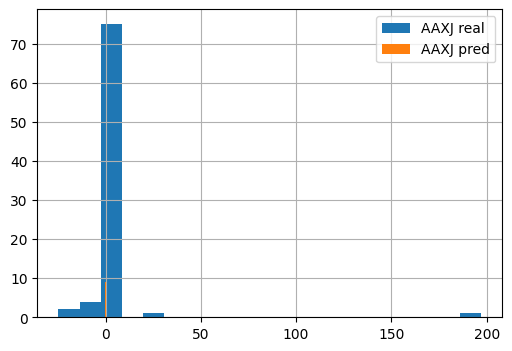

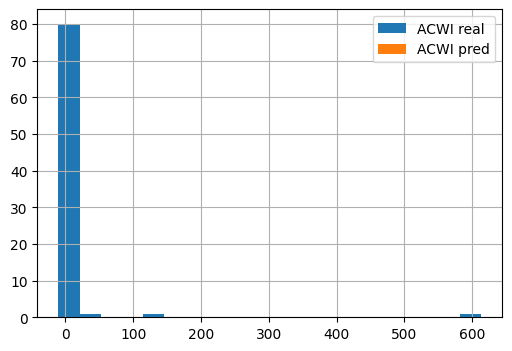

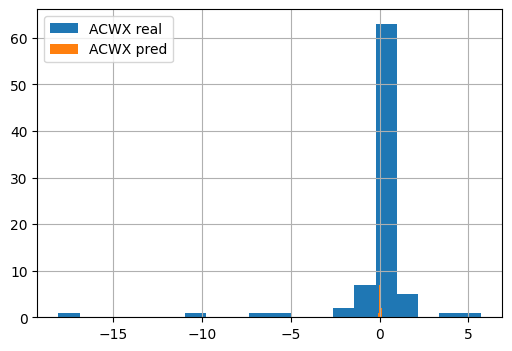

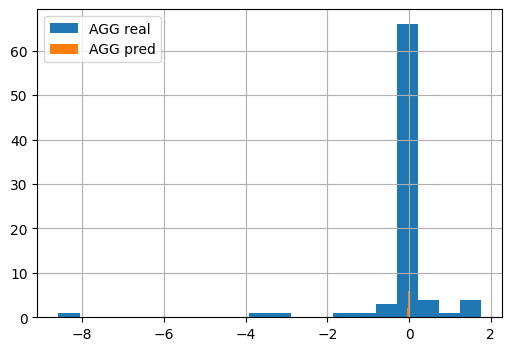

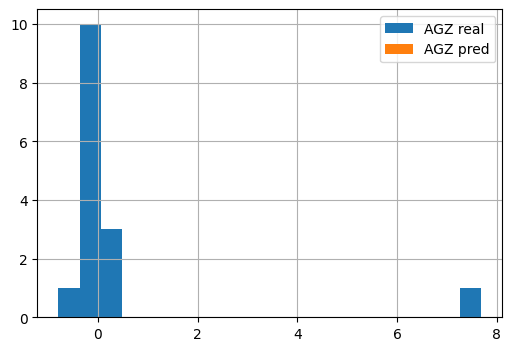

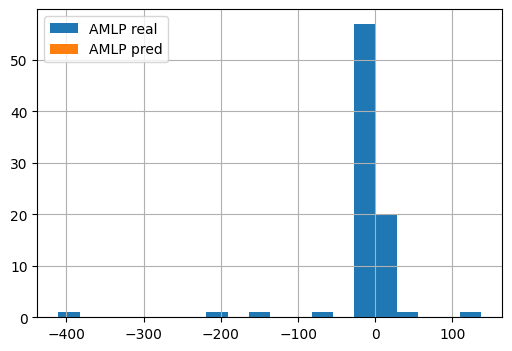

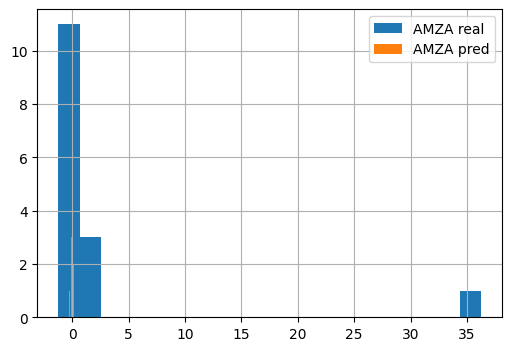

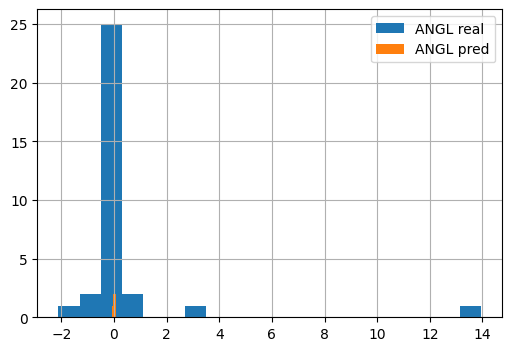

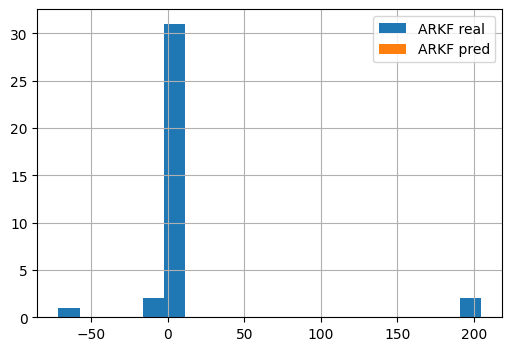

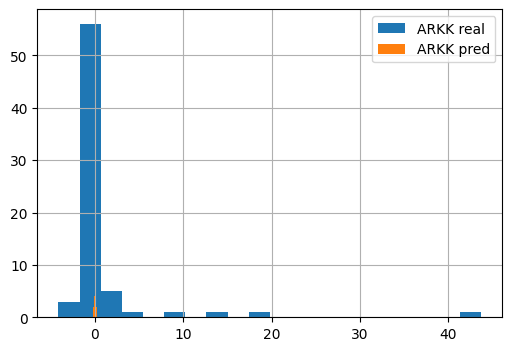

In [ ]:
n = 10

for ticker in df_real.columns[:n]:
    # Histogram
    plt.figure(figsize=(6, 4))
    plt.hist(df_real[ticker], bins=20, label=f"{ticker} real")
    plt.hist(df_preds[ticker], bins=20, label=f"{ticker} pred")
    plt.grid(), plt.legend()

    # # Return
    # plt.figure(figsize=(20, 6))
    # plt.plot(df_real[ticker], 'o', label=f"{ticker} real")
    # plt.plot(df_preds[ticker], 'x', label=f"{ticker} pred")
    # plt.xticks(rotation=45)
    # plt.grid(), plt.legend()


Index(['log_score', 'waic', 'rank_ic', 'mae', 'coverage_95', 'sign_precision',
       'avg_true_positives', 'r_squared', 'rmse', 'avg_predicted_mean',
       'avg_true_mean', 'mean_deviation'],
      dtype='object')


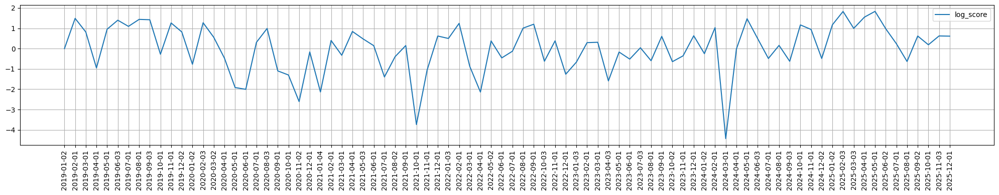

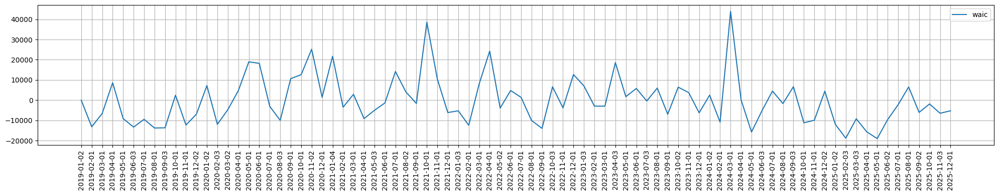

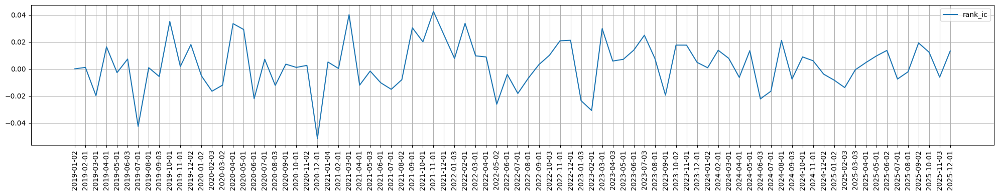

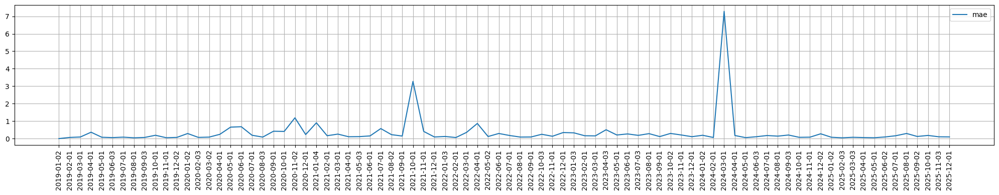

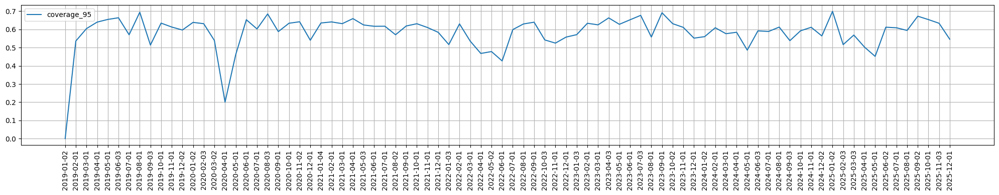

...

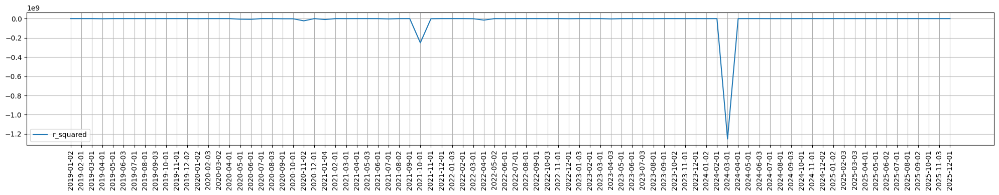

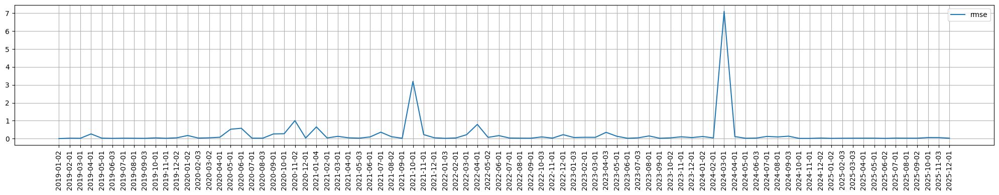

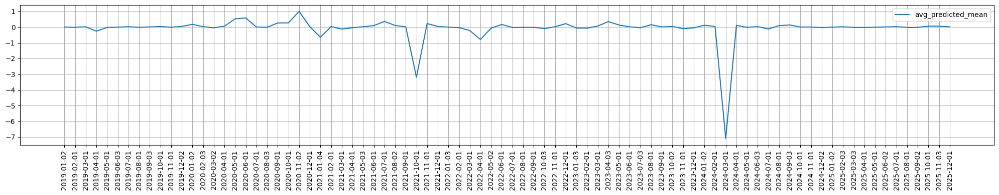

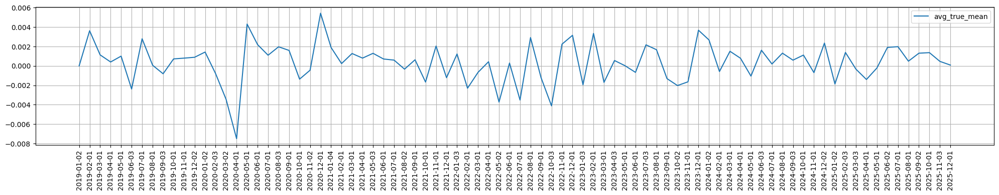

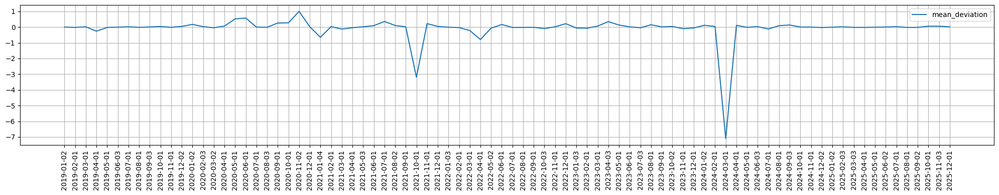

In [5]:
df_model= pd.read_csv(output / "model.csv", index_col=0)
print(df_model.columns)

# plt.plot(df_model[''])
# plt.plot(df_model['sign_precision'])

for col in df_model.columns:
    plt.figure(figsize=(20, 4))
    plt.plot(df_model[col], label=col)
    plt.xticks(rotation=90)
    plt.legend(), plt.grid(), plt.tight_layout()


In [7]:
root = Path.cwd().parent / "scripts/configs/test.yaml"

with open(root, 'rb') as file:
    config = yaml.safe_load(file)

type(config), config


(dict,
 {'balance': 1000.0,
  'model': [{'type': 'bayessian'},
   {'matrix_type': 'fast'},
   {'mean_return': 'sampled'},
   {'distribution': 'normal'},
   {'posterior': 'horseshoe'},
   {'n_samples': 1000}],
  'cvar': [{'type': 'markowitz'},
   {'method': 'SLSQP'},
   {'task_type': 'max_sharpe'},
   {'is_all_methods': True},
   {'is_all_parameters': True},
   {'max_iter': 'None'}],
  'execution': [{'type': 'base_exec'},
   {'return_type': 'log-returns'},
   {'c_bps': '1e-2'}]})

In [42]:
from beartype import beartype
from typing import Any

@beartype
def fun(config: dict[str, Any]):
    print('haha')
    print(config)

fun(config)


haha
{'balance': 1000.0, 'model': [{'type': 'bayessian'}, {'matrix_type': 'fast'}, {'mean_return': 'sampled'}, {'distribution': 't-student'}, {'posteriorType': 'horseshoe'}, {'n_samples': 1000}], 'cvar': [{'type': 'markowitz'}, {'method': 'SLSQP'}, {'max_iter': 'no'}], 'execution': [{'type': 'base_exec'}]}


## weights

In [201]:
first_business_days = pd.read_excel(Path.cwd().parent / "datasets" / "excel" / "business_dates.xlsx", index_col=0)
first_business_days = first_business_days['Values'].iloc[1:]
first_business_days


1     2016-02-01
2     2016-03-01
3     2016-04-01
4     2016-05-02
5     2016-06-01
         ...    
115   2025-08-01
116   2025-09-02
117   2025-10-01
118   2025-11-03
119   2025-12-01
Name: Values, Length: 119, dtype: datetime64[ns]

In [202]:
path = Path.cwd().parent / "datasets" / "excel" / "new.csv"
df = pd.read_csv(path, index_col=0)
etfs = df.columns.sort_values(ascending=True)
etfs


Index(['AAA', 'AAAU', 'AADR', 'AAUS', 'AAXJ', 'ABCS', 'ABEQ', 'ABI', 'ABIG',
       'ABNY',
       ...
       'ZIG', 'ZIPP', 'ZROZ', 'ZSB', 'ZSC', 'ZSPY', 'ZTAX', 'ZTEN', 'ZTOP',
       'ZTWO'],
      dtype='object', length=3133)

In [ ]:
sheet_names_str = [key.strftime('%Y-%m-%d') for key in first_business_days]
weights_rebalance = pd.read_excel(output / "weights.xlsx", sheet_name=sheet_names_str)
weights_rebalance


{'2016-02-01':        Key  Value
 0      AAA      0
 1     AAAU      0
 2     AADR      0
 3     AAUS      0
 4     AAVM      0
 ...    ...    ...
 3549  ZTAX      0
 3550  ZTEN      0
 3551  ZTOP      0
 3552  ZTRE      0
 3553  ZTWO      0
 
 [3554 rows x 2 columns],
 '2016-03-01':        Key  Value
 0      AAA      0
 1     AAAU      0
 2     AADR      0
 3     AAUS      0
 4     AAVM      0
 ...    ...    ...
 3549  ZTAX      0
 3550  ZTEN      0
 3551  ZTOP      0
 3552  ZTRE      0
 3553  ZTWO      0
 
 [3554 rows x 2 columns],
 '2016-04-01':        Key  Value
 0      AAA      0
 1     AAAU      0
 2     AADR      0
 3     AAUS      0
 4     AAVM      0
 ...    ...    ...
 3549  ZTAX      0
 3550  ZTEN      0
 3551  ZTOP      0
 3552  ZTRE      0
 3553  ZTWO      0
 
 [3554 rows x 2 columns],
 '2016-05-02':        Key  Value
 0      AAA      0
 1     AAAU      0
 2     AADR      0
 3     AAUS      0
 4     AAVM      0
 ...    ...    ...
 3549  ZTAX      0
 3550  ZTEN      0
 3551

In [ ]:
tuple(np.array([1, 2, 3]))


(np.int64(1), np.int64(2), np.int64(3))

## Weights rebalancing plotting

/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_2327/3133746718.py:75: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()




In [189]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Change these
excel_file = Path(output / "weights.xlsx")

top_n = 20
data = []

# Read all sheets
sheets = pd.read_excel(excel_file, sheet_name=None)

for sheet_name, df in sheets.items():
    df.columns = df.columns.str.strip()

    if "Key" not in df.columns or "weights" not in df.columns:
        continue

    temp = df[["Key", "weights"]].dropna()
    temp = temp[temp["weights"] > 0]
    temp["date"] = pd.to_datetime(sheet_name)
    temp = temp.rename(columns={"Key": "ETF", "weights": "weight"})

    data.append(temp[["date", "ETF", "weight"]])

# Combine and pivot
df = pd.concat(data)

weights = (
    df.pivot_table(index="date", columns="ETF", values="weight", aggfunc="sum")
    .fillna(0)
    .sort_index()
)

# Convert percentages to decimals if needed
if weights.max().max() > 1.5:
    weights = weights / 100

# Normalize each month to 100%
weights = weights.div(weights.sum(axis=1), axis=0)

# # Keep top ETFs and group the rest - all etfs (1 way)
# top_etfs = weights.max().sort_values(ascending=False).head(top_n).index
# plot_df = weights[top_etfs].copy()
# plot_df["Other ETFs"] = weights.drop(columns=top_etfs).sum(axis=1)

# Keep only ETF weights >= 0.01 at least once - only etfs weights >= 0.01 (2nd way)
min_weight = 0.01
plot_df = weights.loc[:, (weights >= min_weight).any(axis=0)].copy()
plot_df = plot_df.where(plot_df >= min_weight, 0) # Optional: hide tiny weights in months where ETF < 0.01

# Plot stacked bars
ax = plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(18, 8),
    width=0.9
)

ax.set_title("ETF portfolio composition over time")
ax.set_xlabel("Month")
ax.set_ylabel("Portfolio weight")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(title="ETF", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.xticks(
    range(len(plot_df.index)),
    [d.strftime("%Y-%m") for d in plot_df.index],
    rotation=45,
    ha="right"
)

plt.tight_layout()
# output_file = excel_file.parent / "etf_stacked_weights.png"
# plt.savefig(output_file, dpi=180, bbox_inches="tight")
plt.show()

# print(f"Saved chart to: {output_file}")

# NEW FILTRATION + min_weight = 0.01, turnover_penalty = 1.0, alpha_level = 0.99 + with previous weights


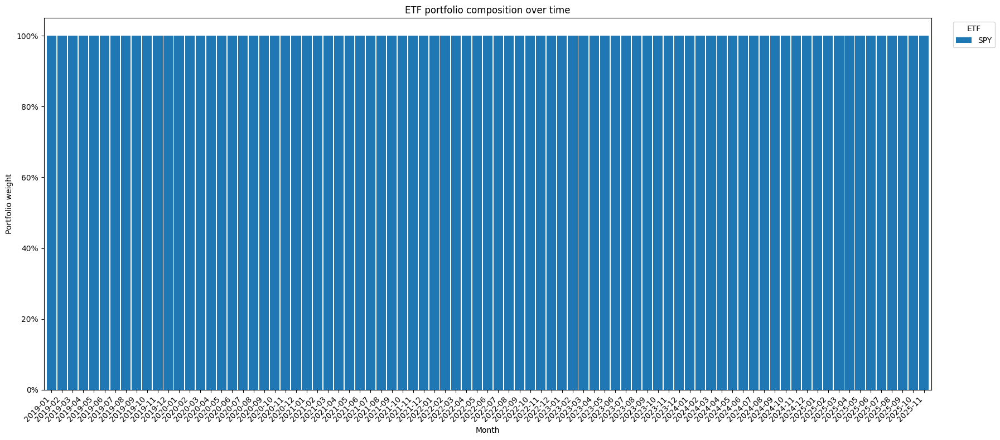

In [181]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Change these
excel_file = Path(output / "weights.xlsx")

top_n = 20
data = []

# Read all sheets
sheets = pd.read_excel(excel_file, sheet_name=None)

for sheet_name, df in sheets.items():
    df.columns = df.columns.str.strip()

    if "Key" not in df.columns or "weights" not in df.columns:
        continue

    temp = df[["Key", "weights"]].dropna()
    temp = temp[temp["weights"] > 0]
    temp["date"] = pd.to_datetime(sheet_name)
    temp = temp.rename(columns={"Key": "ETF", "weights": "weight"})

    data.append(temp[["date", "ETF", "weight"]])

# Combine and pivot
df = pd.concat(data)

weights = (
    df.pivot_table(index="date", columns="ETF", values="weight", aggfunc="sum")
    .fillna(0)
    .sort_index()
)

# Convert percentages to decimals if needed
if weights.max().max() > 1.5:
    weights = weights / 100

# Normalize each month to 100%
weights = weights.div(weights.sum(axis=1), axis=0)

# Keep top ETFs and group the rest - all etfs (1 way)
top_etfs = weights.max().sort_values(ascending=False).head(top_n).index
plot_df = weights[top_etfs].copy()
plot_df["Other ETFs"] = weights.drop(columns=top_etfs).sum(axis=1)

# # Keep only ETF weights >= 0.001 at least once - only etfs weights >= 0.001 (2nd way)
# min_weight = 0.001
# plot_df = weights.loc[:, (weights >= min_weight).any(axis=0)].copy()
# plot_df = plot_df.where(plot_df >= min_weight, 0) # Optional: hide tiny weights in months where ETF < 0.001

# Plot stacked bars
ax = plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(18, 8),
    width=0.9
)

ax.set_title("ETF portfolio composition over time")
ax.set_xlabel("Month")
ax.set_ylabel("Portfolio weight")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(title="ETF", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.xticks(
    range(len(plot_df.index)),
    [d.strftime("%Y-%m") for d in plot_df.index],
    rotation=45,
    ha="right"
)

plt.tight_layout()
# output_file = excel_file.parent / "etf_stacked_weights.png"
# plt.savefig(output_file, dpi=180, bbox_inches="tight")
plt.show()

# print(f"Saved chart to: {output_file}")

# min_weight = 0.01, turnover_penalty = 1.0, alpha_level = 0.99 + with previous weights


/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_2327/1969407678.py:75: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


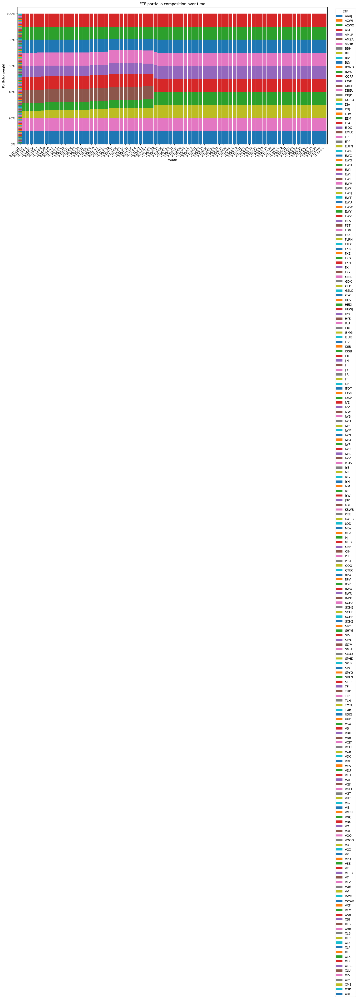

In [168]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Change these
excel_file = Path(output / "weights.xlsx")

top_n = 20
data = []

# Read all sheets
sheets = pd.read_excel(excel_file, sheet_name=None)

for sheet_name, df in sheets.items():
    df.columns = df.columns.str.strip()

    if "Key" not in df.columns or "weights" not in df.columns:
        continue

    temp = df[["Key", "weights"]].dropna()
    temp = temp[temp["weights"] > 0]
    temp["date"] = pd.to_datetime(sheet_name)
    temp = temp.rename(columns={"Key": "ETF", "weights": "weight"})

    data.append(temp[["date", "ETF", "weight"]])

# Combine and pivot
df = pd.concat(data)

weights = (
    df.pivot_table(index="date", columns="ETF", values="weight", aggfunc="sum")
    .fillna(0)
    .sort_index()
)

# Convert percentages to decimals if needed
if weights.max().max() > 1.5:
    weights = weights / 100

# Normalize each month to 100%
weights = weights.div(weights.sum(axis=1), axis=0)

# # Keep top ETFs and group the rest - all etfs (1 way)
# top_etfs = weights.max().sort_values(ascending=False).head(top_n).index
# plot_df = weights[top_etfs].copy()
# plot_df["Other ETFs"] = weights.drop(columns=top_etfs).sum(axis=1)

# Keep only ETF weights >= 0.001 at least once - only etfs weights >= 0.001 (2nd way)
min_weight = 0.001
plot_df = weights.loc[:, (weights >= min_weight).any(axis=0)].copy()
plot_df = plot_df.where(plot_df >= min_weight, 0) # Optional: hide tiny weights in months where ETF < 0.001

# Plot stacked bars
ax = plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(18, 8),
    width=0.9
)

ax.set_title("ETF portfolio composition over time")
ax.set_xlabel("Month")
ax.set_ylabel("Portfolio weight")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(title="ETF", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.xticks(
    range(len(plot_df.index)),
    [d.strftime("%Y-%m") for d in plot_df.index],
    rotation=45,
    ha="right"
)

plt.tight_layout()
# output_file = excel_file.parent / "etf_stacked_weights.png"
# plt.savefig(output_file, dpi=180, bbox_inches="tight")
plt.show()

# print(f"Saved chart to: {output_file}")

# min_weight = 0.01, turnover_penalty = 1.0, alpha_level = 0.99 + with previous weights


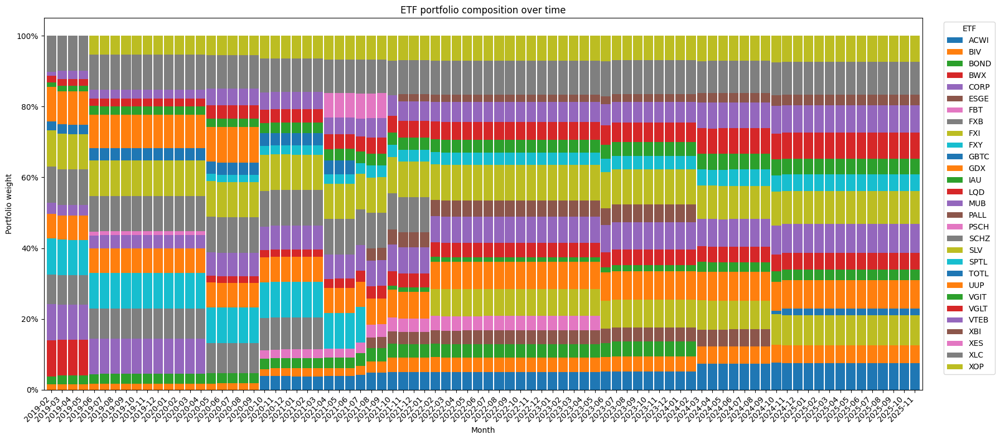

In [167]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Change these
excel_file = Path(output / "weights.xlsx")

top_n = 20
data = []

# Read all sheets
sheets = pd.read_excel(excel_file, sheet_name=None)

for sheet_name, df in sheets.items():
    df.columns = df.columns.str.strip()

    if "Key" not in df.columns or "weights" not in df.columns:
        continue

    temp = df[["Key", "weights"]].dropna()
    temp = temp[temp["weights"] > 0]
    temp["date"] = pd.to_datetime(sheet_name)
    temp = temp.rename(columns={"Key": "ETF", "weights": "weight"})

    data.append(temp[["date", "ETF", "weight"]])

# Combine and pivot
df = pd.concat(data)

weights = (
    df.pivot_table(index="date", columns="ETF", values="weight", aggfunc="sum")
    .fillna(0)
    .sort_index()
)

# Convert percentages to decimals if needed
if weights.max().max() > 1.5:
    weights = weights / 100

# Normalize each month to 100%
weights = weights.div(weights.sum(axis=1), axis=0)

# # Keep top ETFs and group the rest - all etfs (1 way)
# top_etfs = weights.max().sort_values(ascending=False).head(top_n).index
# plot_df = weights[top_etfs].copy()
# plot_df["Other ETFs"] = weights.drop(columns=top_etfs).sum(axis=1)

# Keep only ETF weights >= 0.001 at least once - only etfs weights >= 0.001 (2nd way)
min_weight = 0.001
plot_df = weights.loc[:, (weights >= min_weight).any(axis=0)].copy()
plot_df = plot_df.where(plot_df >= min_weight, 0) # Optional: hide tiny weights in months where ETF < 0.001

# Plot stacked bars
ax = plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(18, 8),
    width=0.9
)

ax.set_title("ETF portfolio composition over time")
ax.set_xlabel("Month")
ax.set_ylabel("Portfolio weight")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(title="ETF", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.xticks(
    range(len(plot_df.index)),
    [d.strftime("%Y-%m") for d in plot_df.index],
    rotation=45,
    ha="right"
)

plt.tight_layout()
# output_file = excel_file.parent / "etf_stacked_weights.png"
# plt.savefig(output_file, dpi=180, bbox_inches="tight")
plt.show()

# print(f"Saved chart to: {output_file}")

# min_weight = 0.01, turnover_penalty = 1.0, alpha_level = 0.99 + without previous weights


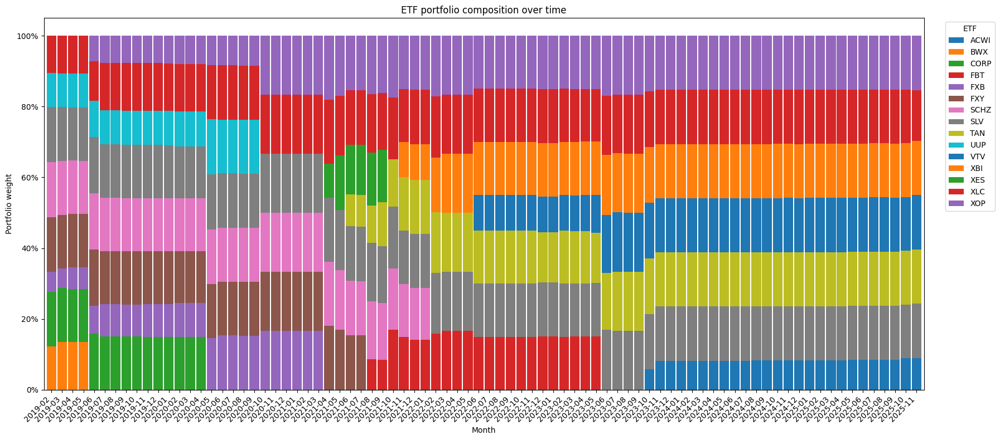

In [164]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Change these
excel_file = Path(output / "weights.xlsx")

top_n = 20
data = []

# Read all sheets
sheets = pd.read_excel(excel_file, sheet_name=None)

for sheet_name, df in sheets.items():
    df.columns = df.columns.str.strip()

    if "Key" not in df.columns or "weights" not in df.columns:
        continue

    temp = df[["Key", "weights"]].dropna()
    temp = temp[temp["weights"] > 0]
    temp["date"] = pd.to_datetime(sheet_name)
    temp = temp.rename(columns={"Key": "ETF", "weights": "weight"})

    data.append(temp[["date", "ETF", "weight"]])

# Combine and pivot
df = pd.concat(data)

weights = (
    df.pivot_table(index="date", columns="ETF", values="weight", aggfunc="sum")
    .fillna(0)
    .sort_index()
)

# Convert percentages to decimals if needed
if weights.max().max() > 1.5:
    weights = weights / 100

# Normalize each month to 100%
weights = weights.div(weights.sum(axis=1), axis=0)

# # Keep top ETFs and group the rest - all etfs
# top_etfs = weights.max().sort_values(ascending=False).head(top_n).index
# plot_df = weights[top_etfs].copy()
# plot_df["Other ETFs"] = weights.drop(columns=top_etfs).sum(axis=1)

# Keep only ETF weights >= 0.001 at least once
min_weight = 0.001
plot_df = weights.loc[:, (weights >= min_weight).any(axis=0)].copy()

# Optional: hide tiny weights in months where ETF < 0.001
plot_df = plot_df.where(plot_df >= min_weight, 0)

# Plot stacked bars
ax = plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(18, 8),
    width=0.9
)

ax.set_title("ETF portfolio composition over time")
ax.set_xlabel("Month")
ax.set_ylabel("Portfolio weight")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(title="ETF", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.xticks(
    range(len(plot_df.index)),
    [d.strftime("%Y-%m") for d in plot_df.index],
    rotation=45,
    ha="right"
)

plt.tight_layout()
# output_file = excel_file.parent / "etf_stacked_weights.png"
# plt.savefig(output_file, dpi=180, bbox_inches="tight")
plt.show()

# print(f"Saved chart to: {output_file}")

# min_weight = 0.5, turnover_penalty = 0.5, alpha_level = 0.95 + without previous weights


/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_2327/4289494570.py:77: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


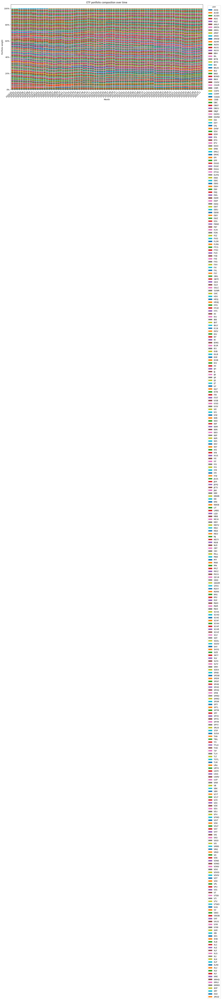

In [163]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Change these
excel_file = Path(output / "weights.xlsx")

top_n = 20
data = []

# Read all sheets
sheets = pd.read_excel(excel_file, sheet_name=None)

for sheet_name, df in sheets.items():
    df.columns = df.columns.str.strip()

    if "Key" not in df.columns or "weights" not in df.columns:
        continue

    temp = df[["Key", "weights"]].dropna()
    temp = temp[temp["weights"] > 0]
    temp["date"] = pd.to_datetime(sheet_name)
    temp = temp.rename(columns={"Key": "ETF", "weights": "weight"})

    data.append(temp[["date", "ETF", "weight"]])

# Combine and pivot
df = pd.concat(data)

weights = (
    df.pivot_table(index="date", columns="ETF", values="weight", aggfunc="sum")
    .fillna(0)
    .sort_index()
)

# Convert percentages to decimals if needed
if weights.max().max() > 1.5:
    weights = weights / 100

# Normalize each month to 100%
weights = weights.div(weights.sum(axis=1), axis=0)

# # Keep top ETFs and group the rest - all etfs
# top_etfs = weights.max().sort_values(ascending=False).head(top_n).index
# plot_df = weights[top_etfs].copy()
# plot_df["Other ETFs"] = weights.drop(columns=top_etfs).sum(axis=1)

# Keep only ETF weights >= 0.001 at least once
min_weight = 0.001
plot_df = weights.loc[:, (weights >= min_weight).any(axis=0)].copy()

# Optional: hide tiny weights in months where ETF < 0.001
plot_df = plot_df.where(plot_df >= min_weight, 0)

# Plot stacked bars
ax = plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(18, 8),
    width=0.9
)

ax.set_title("ETF portfolio composition over time")
ax.set_xlabel("Month")
ax.set_ylabel("Portfolio weight")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(title="ETF", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.xticks(
    range(len(plot_df.index)),
    [d.strftime("%Y-%m") for d in plot_df.index],
    rotation=45,
    ha="right"
)

plt.tight_layout()
# output_file = excel_file.parent / "etf_stacked_weights.png"
# plt.savefig(output_file, dpi=180, bbox_inches="tight")
plt.show()

# print(f"Saved chart to: {output_file}")


### old plots

In [158]:
indexes = []
for ind, date in enumerate(first_business_days):
    if 'weights' in weights_rebalance[date.strftime("%Y-%m-%d")].columns:
        indexes.append(ind)


In [159]:
index = indexes[-1]
weights_dates = list(weights_rebalance.keys())
mask = weights_rebalance[weights_dates[index]]['weights'].apply(lambda x: x > 0)
weights_rebalance[weights_dates[index]][mask]


,Key,Value,weights
5,AAXJ,1,0.004411
20,ACWI,1,0.004641
21,ACWX,1,0.004094
36,AGG,1,0.004774
87,AMLP,1,0.004631
...,...,...,...
3479,XMMO,1,0.003175
3486,XOP,1,0.005665
3496,XRT,1,0.005140
3497,XSD,1,0.004256


In [160]:
for index in indexes:
    weights_dates = list(weights_rebalance.keys())
    mask = weights_rebalance[weights_dates[index]]['weights'].apply(lambda x: x > 0)
    print(weights_rebalance[weights_dates[index]][mask]['Key'])
    


5       AAXJ
20      ACWI
21      ACWX
36       AGG
87      AMLP
        ... 
3471     XLV
3473     XLY
3476     XME
3486     XOP
3496     XRT
Name: Key, Length: 211, dtype: object
5       AAXJ
20      ACWI
21      ACWX
36       AGG
87      AMLP
        ... 
3471     XLV
3473     XLY
3476     XME
3486     XOP
3496     XRT
Name: Key, Length: 213, dtype: object
5       AAXJ
20      ACWI
21      ACWX
36       AGG
87      AMLP
        ... 
3471     XLV
3473     XLY
3476     XME
3486     XOP
3496     XRT
Name: Key, Length: 216, dtype: object
5       AAXJ
20      ACWI
21      ACWX
36       AGG
87      AMLP
        ... 
3473     XLY
3476     XME
3486     XOP
3496     XRT
3497     XSD
Name: Key, Length: 217, dtype: object
5       AAXJ
20      ACWI
21      ACWX
36       AGG
87      AMLP
        ... 
3473     XLY
3476     XME
3486     XOP
3496     XRT
3497     XSD
Name: Key, Length: 217, dtype: object
5       AAXJ
20      ACWI
21      ACWX
36       AGG
87      AMLP
        ... 
3473     XLY
3476

In [162]:
df = weights_rebalance[weights_dates[index]][mask]
df_sorted = df.sort_values("weights", ascending=False)
df_sorted


,Key,Value,weights
1258,FXI,1,0.006423
2069,MCHI,1,0.006354
124,ASHR,1,0.005760
3486,XOP,1,0.005665
1515,IAU,1,0.005560
...,...,...,...
2220,NLR,1,0.002650
435,CGGR,1,0.002650
2414,PPLT,1,0.002650
500,COPX,1,0.002650


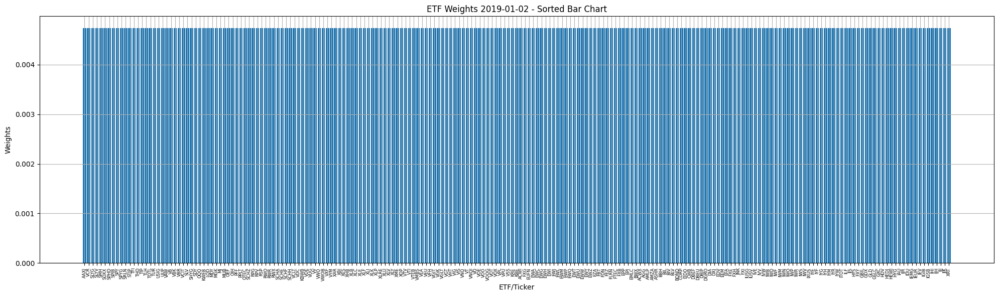

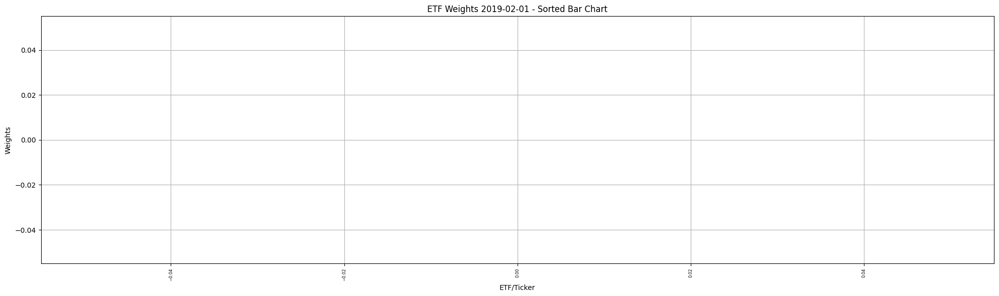

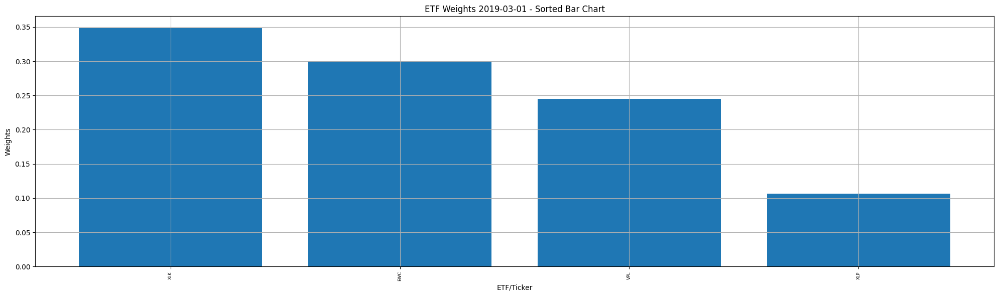

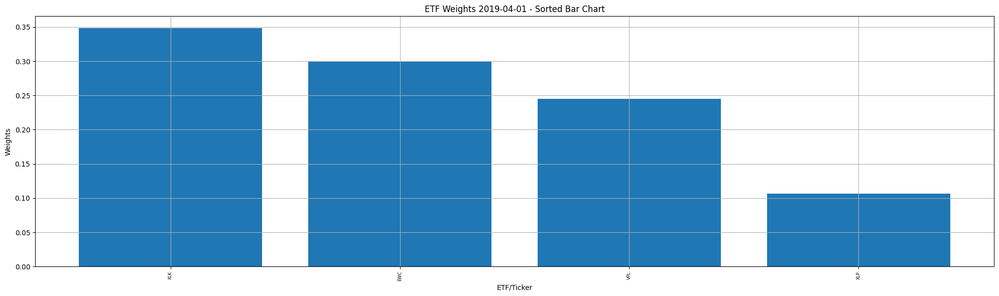

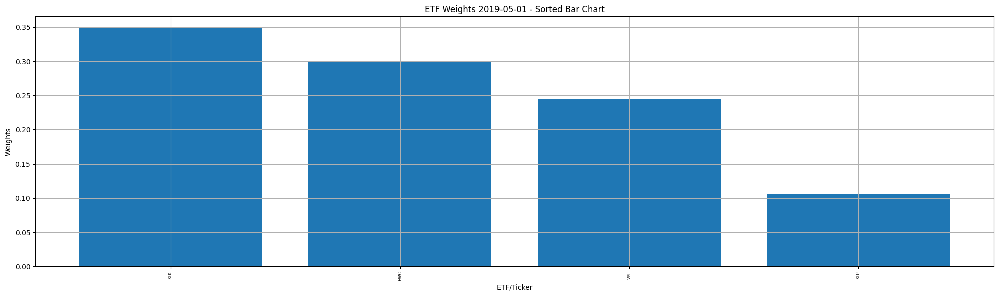

...

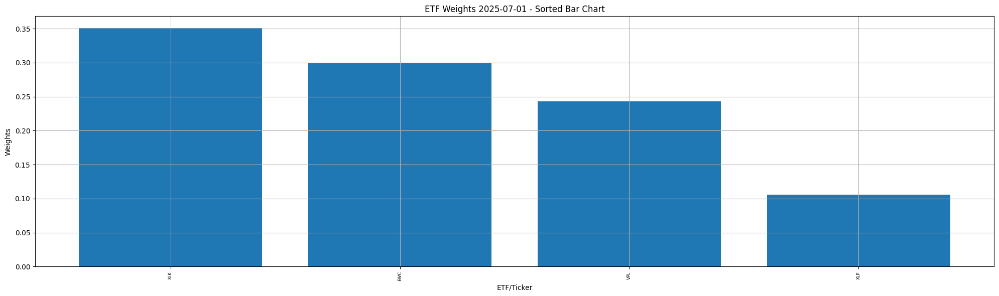

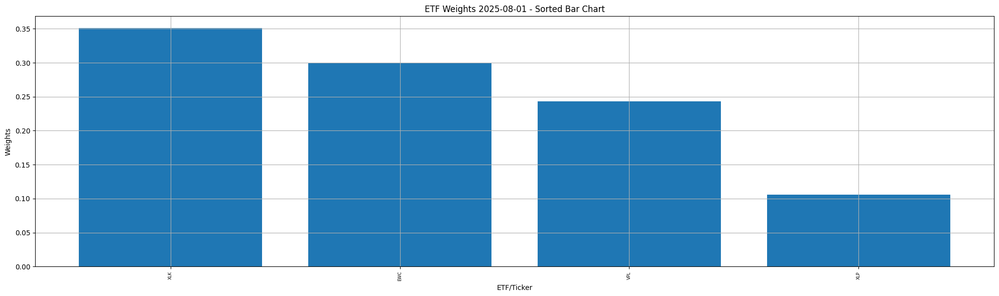

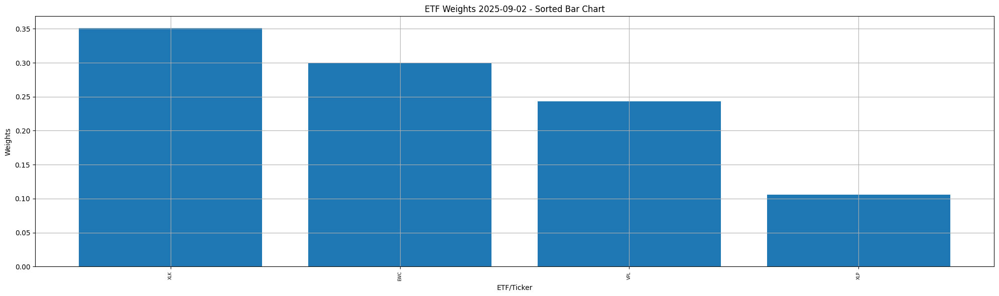

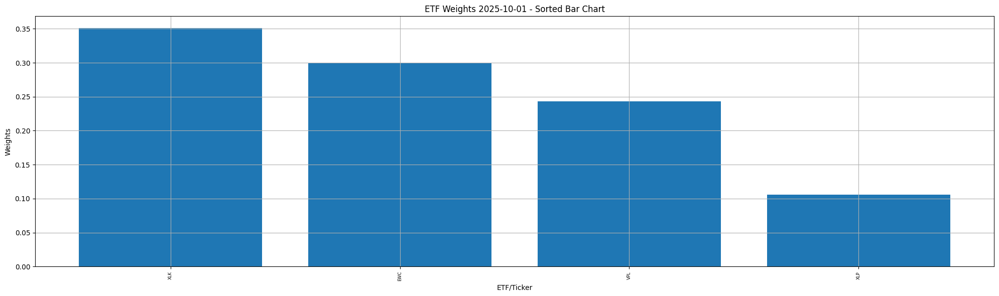

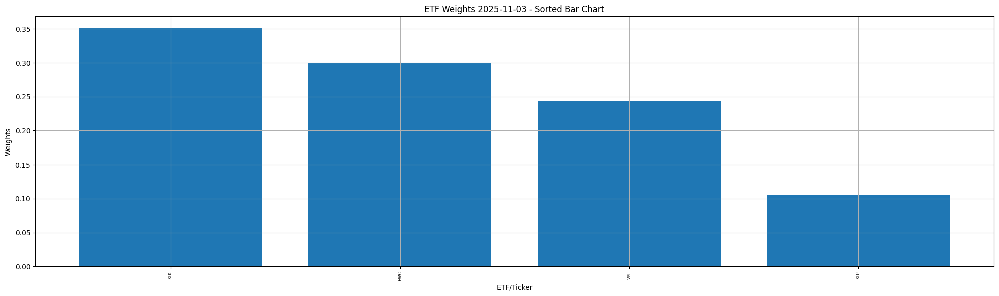

In [150]:
weights_dates = list(weights_rebalance.keys())
for index in indexes:
    date = weights_dates[index]
    mask = weights_rebalance[date]['weights'].apply(lambda x: x > 0)
    df = weights_rebalance[date][mask]
    df_sorted = df.sort_values("weights", ascending=False)
    
    plt.figure(figsize=(20, 6))
    plt.bar(df_sorted['Key'], df_sorted['weights'])

    plt.xlabel('ETF/Ticker')
    plt.ylabel('Weights')
    plt.title(f'ETF Weights {date} - Sorted Bar Chart')
    plt.xticks(rotation=90, fontsize=6)
    plt.grid(), plt.tight_layout(), plt.show()


## Multiple etfs

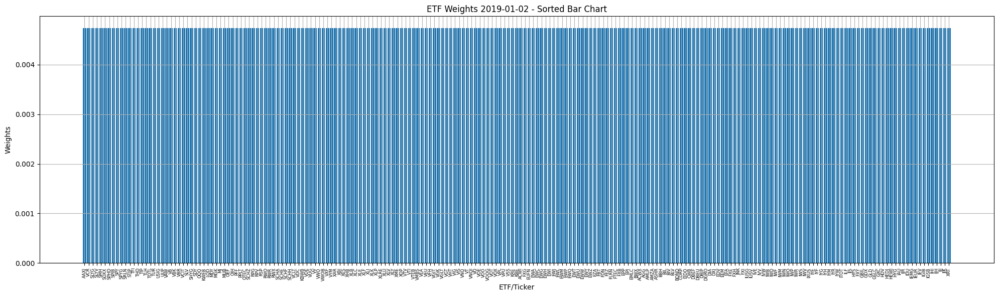

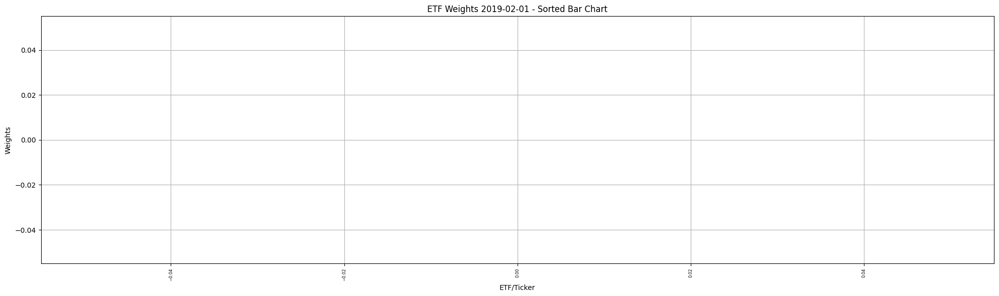

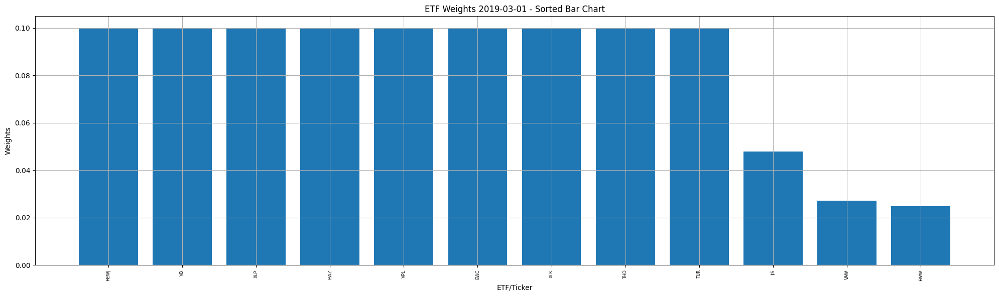

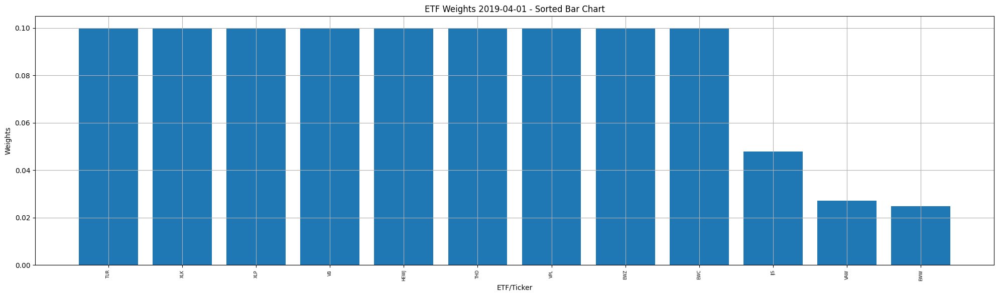

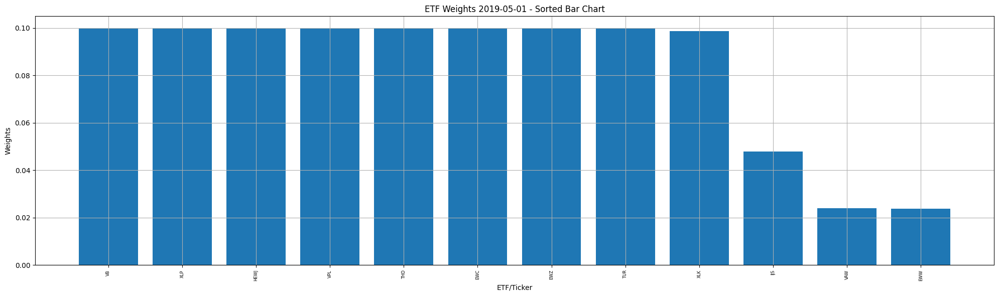

...

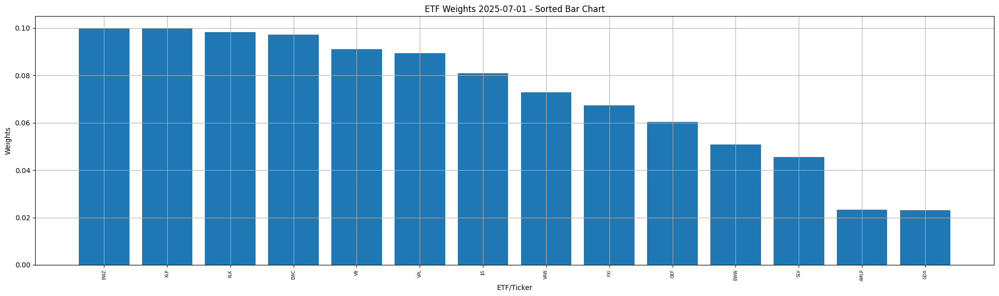

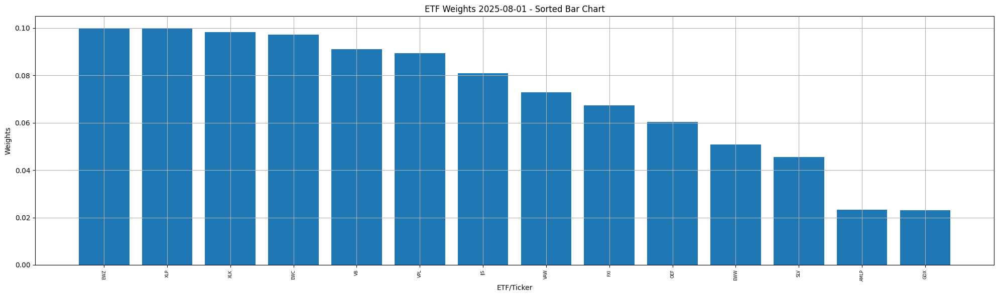

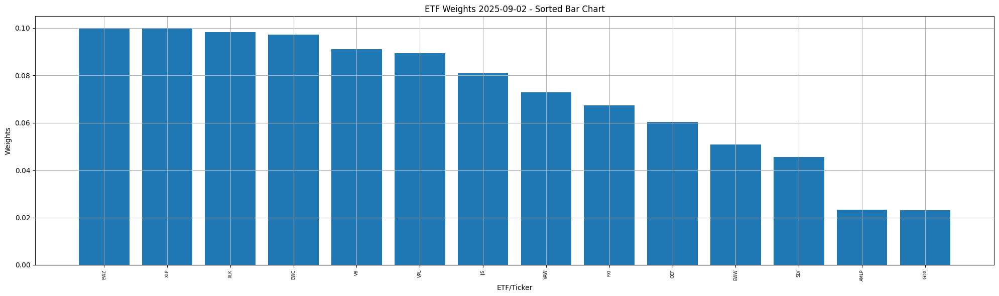

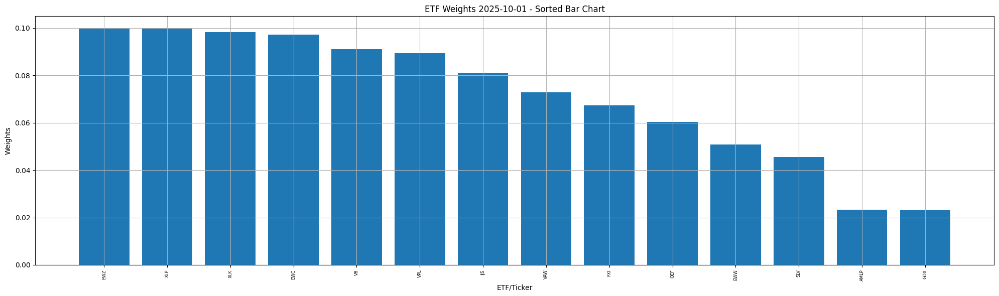

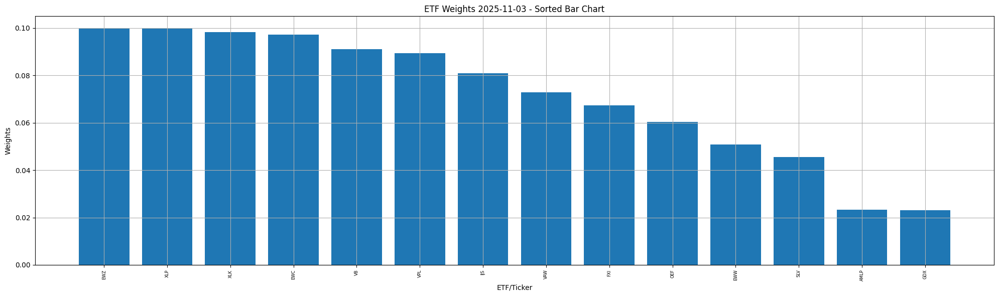

In [53]:
weights_dates = list(weights_rebalance.keys())
for index in indexes:
    date = weights_dates[index]
    mask = weights_rebalance[date]['weights'].apply(lambda x: x > 0)
    df = weights_rebalance[date][mask]
    df_sorted = df.sort_values("weights", ascending=False)
    
    plt.figure(figsize=(20, 6))
    plt.bar(df_sorted['Key'], df_sorted['weights'])

    plt.xlabel('ETF/Ticker')
    plt.ylabel('Weights')
    plt.title(f'ETF Weights {date} - Sorted Bar Chart')
    plt.xticks(rotation=90, fontsize=6)
    plt.grid(), plt.tight_layout(), plt.show()


## Single etfs

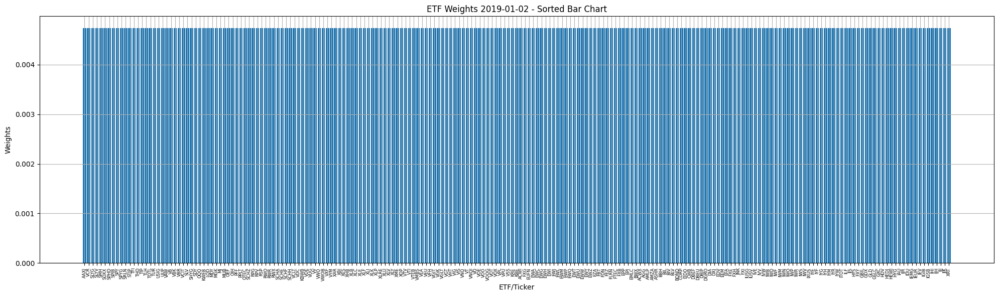

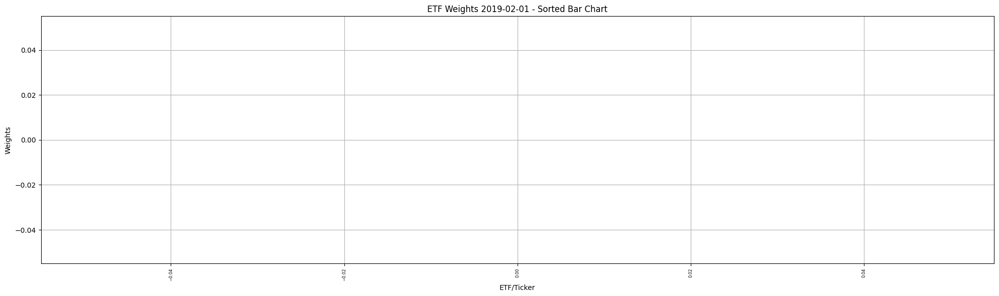

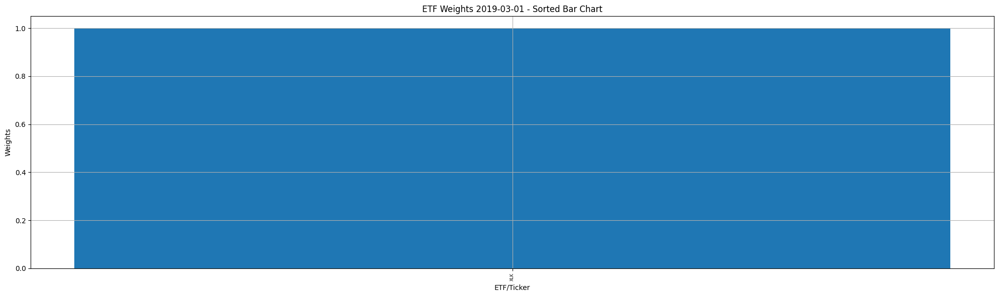

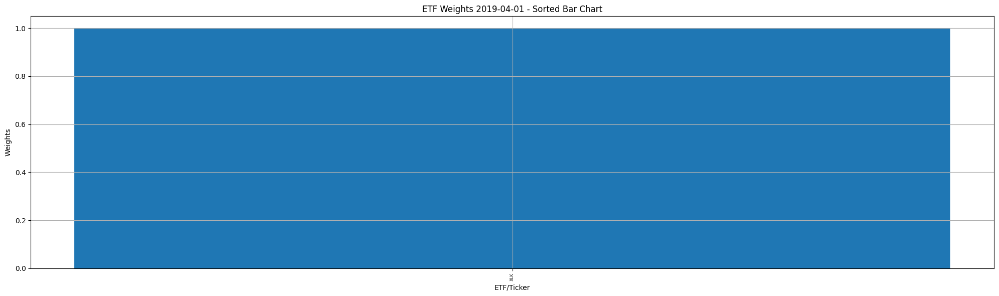

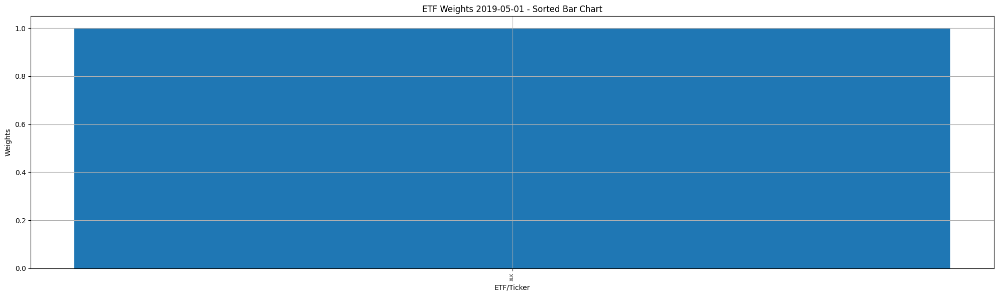

...

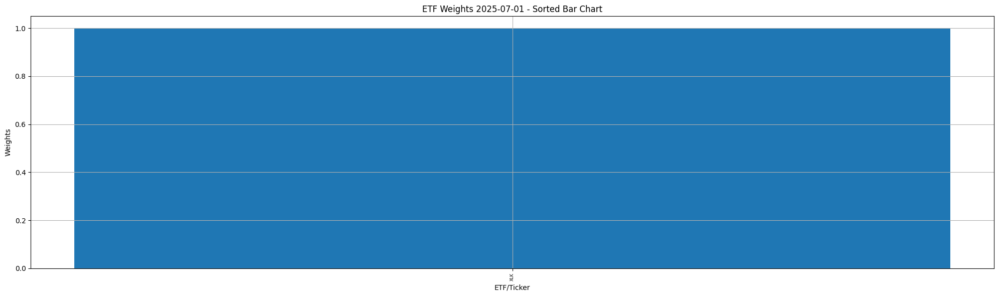

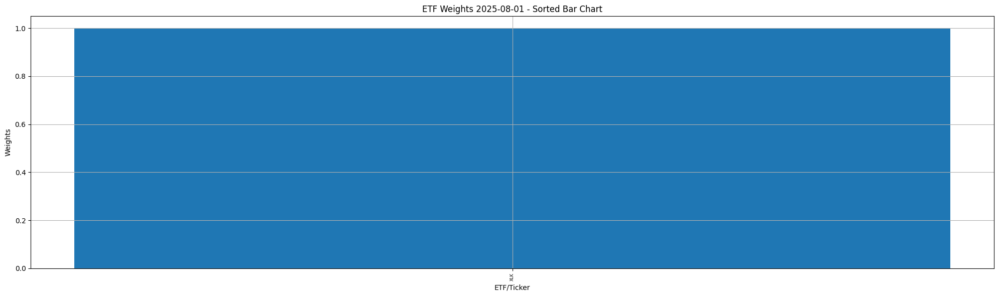

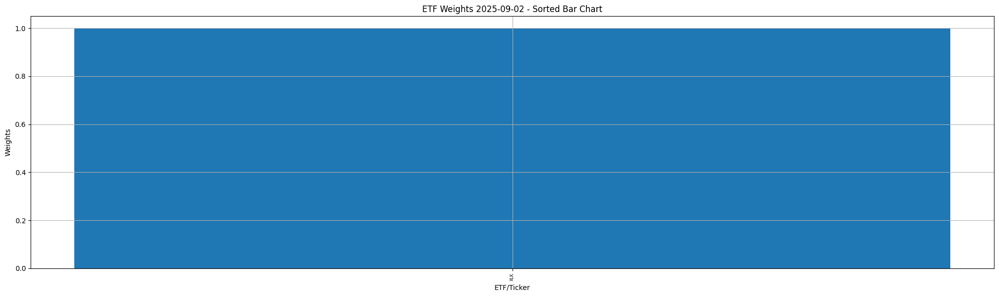

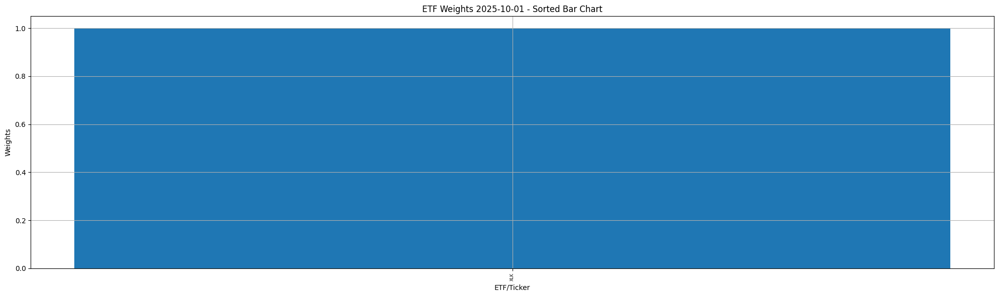

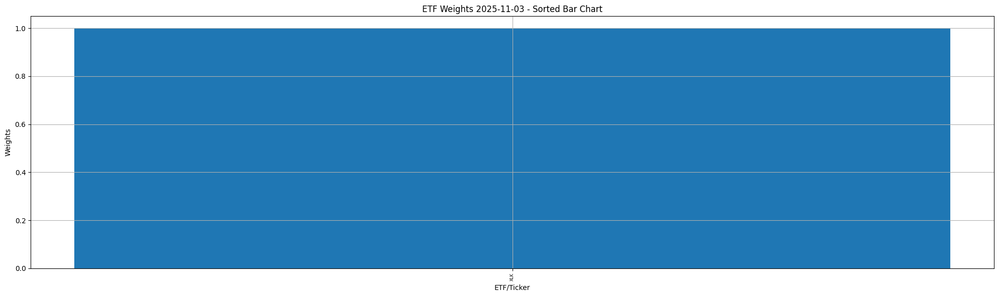

In [64]:
weights_dates = list(weights_rebalance.keys())
for index in indexes:
    date = weights_dates[index]
    mask = weights_rebalance[date]['weights'].apply(lambda x: x > 0)
    df = weights_rebalance[date][mask]
    df_sorted = df.sort_values("weights", ascending=False)
    
    plt.figure(figsize=(20, 6))
    plt.bar(df_sorted['Key'], df_sorted['weights'])

    plt.xlabel('ETF/Ticker')
    plt.ylabel('Weights')
    plt.title(f'ETF Weights {date} - Sorted Bar Chart')
    plt.xticks(rotation=90, fontsize=6)
    plt.grid(), plt.tight_layout(), plt.show()


In [54]:
df[df["weights"] >= 1e-2]


,Key,Value,weights
1325,GLD,1,0.046490
1810,IYW,1,0.054533
2598,RDVY,1,0.193570
2706,RWR,1,0.200000
2854,SMH,1,0.200000
2955,SRLN,1,0.200000
3317,VONV,1,0.054076
3465,XLRE,1,0.051327


In [107]:
weights_rebalance['2019-01-02']


,Key,Value,weights
0,AAA,0,0.0
1,AAAU,0,0.0
2,AADR,0,0.0
3,AAUS,0,0.0
4,AAVM,0,0.0
...,...,...,...
3549,ZTAX,0,0.0
3550,ZTEN,0,0.0
3551,ZTOP,0,0.0
3552,ZTRE,0,0.0
